# 04 - Customer segmentation
_Synthetic data._

Two lenses: rule-based CRM segments for every customer (actionable today) and K-Means clusters on borrower behaviour and value (discovery).

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from python import visualize as viz   # shared chart style (palette, fonts, grid)
%matplotlib inline
from python.config import get_settings
S = get_settings(base_dir=ROOT)
con = duckdb.connect(str(S.warehouse_path), read_only=True)
q = lambda sql: con.execute(sql).df()
pd.set_option("display.max_columns", 30); pd.set_option("display.width", 160)
print("Warehouse:", S.warehouse_path.name, "| as of", S.end_date, "| SYNTHETIC DATA")

Warehouse: fintech.duckdb | as of 2026-06-30 | SYNTHETIC DATA


In [2]:
pd.read_csv(S.outputs_dir/'segments'/'business_segments.csv')[['business_segment','rule','customers','share_of_customers_pct','share_of_net_revenue_pct','recommended_action']]

,business_segment,rule,customers,share_of_customers_pct,share_of_net_revenue_pct,recommended_action
0,High-risk,"current DPD >= 30, any loan written off, or ev...",491,0.604680,-18.971084,Collections workflow; block new credit; hardsh...
1,New customers,signed up in the last 30 days,4388,5.403941,1.143000,"Onboarding nudges: KYC reminders, first-loan o..."
2,High-value repeat,"2+ loans, net revenue in the top quartile of b...",1260,1.551724,33.442004,"Retention: pre-approved top-ups, rate discount..."
3,High-engagement,"top 20% of 90-day app activity, not in the seg...",11848,14.591133,52.654487,Cross-sell and referral asks; beta-test new fe...
4,Onboarding drop-off,KYC not verified and signed up 30+ days ago,30026,36.977833,0.000000,"Win-back: DigiLocker one-tap KYC, assisted KYC..."
5,Inactive,no app activity in the last 90 days,25800,31.773399,19.377031,Re-activation campaign only if previously prof...
6,"Verified, never borrowed","KYC verified, no loan yet, active in the last ...",5919,7.289409,0.000000,Pre-qualified offer; explain eligibility; EMI ...
7,Core borrowers,"everyone else (active, mid-value)",1468,1.807882,12.354562,"Autopay adoption, on-time payment rewards, nex..."


## Choosing k: silhouette with an interpretability constraint (4-6 clusters)

In [3]:
ks = pd.read_csv(S.outputs_dir/'segments'/'k_selection.csv'); ks

,k,inertia,silhouette
0,3,112325.524581,0.253658
1,4,99600.698183,0.167489
2,5,88857.691878,0.187022
3,6,79674.022937,0.199666
4,7,73815.913024,0.201830
5,8,67415.496612,0.207989


In [4]:
pd.read_csv(S.outputs_dir/'segments'/'cluster_profiles.csv').round(2)

,cluster,cluster_name,borrowers,n_loans,total_disbursed,net_revenue,on_time_rate,max_dpd_ever,logins_90d,active_months,n_products,autopay_ever,days_since_last_loan,support_tickets,share_of_borrowers_pct,share_of_net_revenue_pct,share_of_outstanding_pct,recommended_action
0,0,Chronic late payers,1502,1.14,48574.97,4409.12,0.33,30.36,2.86,5.76,1.00,0.47,267.57,0.30,10.72,10.28,10.03,"Pre-due reminders, enforce autopay, hold limit..."
1,1,New & ramping,3703,1.24,48115.74,2382.43,0.97,0.18,4.98,3.28,1.00,0.72,67.23,0.03,26.42,13.69,42.10,"Nurture to a second loan: autopay set-up, on-t..."
2,2,High-value borrowers,3484,1.67,109080.22,12802.48,0.89,3.60,4.25,10.83,1.00,0.65,314.90,0.12,24.86,69.22,32.34,"Protect: dedicated top-up offers, credit-line ..."
3,3,Credit-stressed,279,1.20,62721.86,-48089.47,0.18,362.06,2.83,10.28,1.05,0.52,423.02,0.48,1.99,-20.82,0.00,Collections / hardship restructuring; suppress...
4,4,Lapsed one-time borrowers,3835,1.21,23276.90,1500.45,0.95,0.64,0.15,5.18,1.00,0.51,402.73,0.05,27.37,8.93,0.96,Low-cost re-activation (WhatsApp/email) for pr...
5,5,Loyal repeat borrowers,1211,2.94,125459.62,9949.02,0.87,5.70,4.83,11.07,2.04,0.88,203.48,0.13,8.64,18.70,14.59,"Loyalty pricing, pre-approved repeat offers at..."


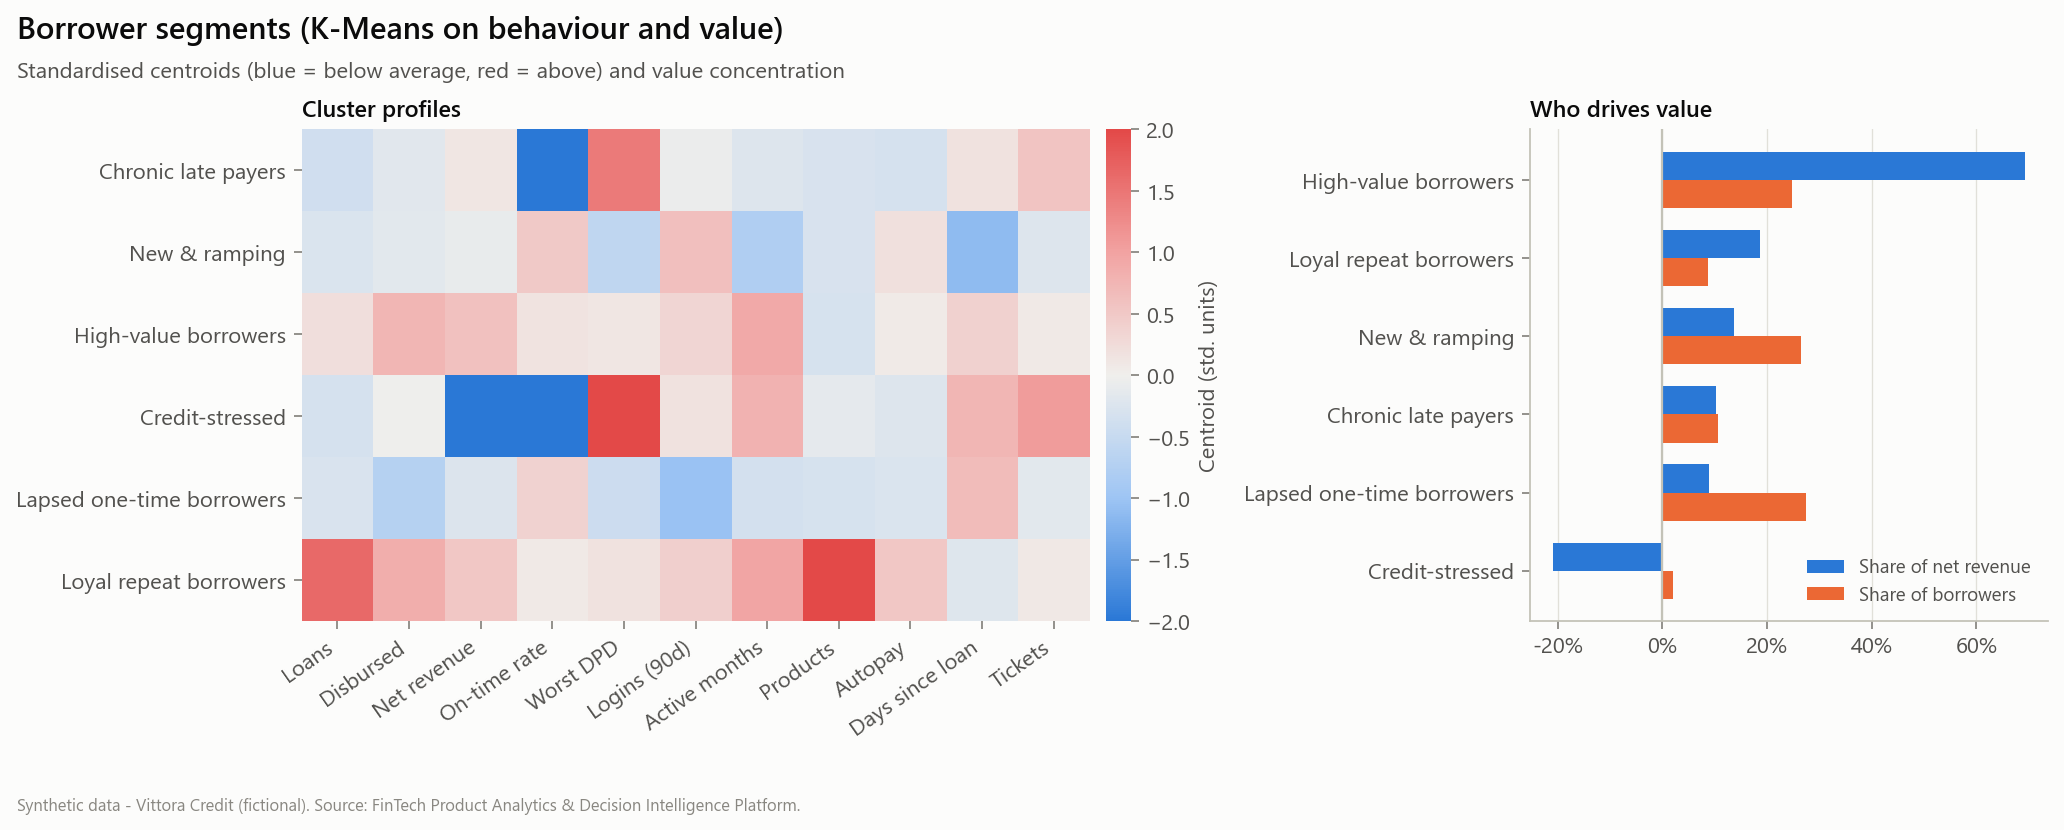

In [5]:
from IPython.display import Image
Image(filename=str(S.images_dir/'segments.png'))

**Business reading:** a small loyal high-value group carries a disproportionate share of net revenue - protect it with pre-approved top-ups; the credit-stressed cluster is negative-value and belongs in collections, not in marketing audiences; lapsed one-time borrowers are the cheapest re-activation pool.